In [1]:
import pandas as pd

df = pd.read_csv("../data/telecom_dataset.csv")

df.head()

,tower_lat,tower_lon,user_lat,user_lon,distance_km,frequency,tx_power,tower_height,antenna_gain,environment,building_density,terrain_height,shadow_fading,rain_loss,user_density,traffic_load,path_loss,received_power,rsrp
0,8.772803,79.601511,8.348193,81.220791,184.202906,700,40,50,20,Rural,0.044,412.71,3.55,1.189,954.31,0.809,134.647890,-79.386890,-82.386890
1,8.477245,81.539348,6.724820,81.560330,194.874487,3500,43,30,15,Suburban,0.547,55.40,5.07,0.684,28.56,0.204,149.116461,-96.870461,-99.870461
2,8.547476,80.296990,8.629913,80.816295,57.827614,2100,46,50,20,Urban,0.885,70.63,9.12,0.000,1227.02,0.875,134.127091,-77.247091,-80.247091
3,8.607987,79.509811,8.134189,79.992761,74.821865,3500,46,20,15,Rural,0.258,159.33,3.49,1.291,933.28,0.632,140.801931,-84.582931,-87.582931
4,8.630686,81.193634,8.028912,80.930730,72.898333,700,43,30,20,Urban,0.755,78.94,10.62,0.000,31.17,0.157,126.596313,-74.216313,-77.216313


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tower_lat         100000 non-null  float64
 1   tower_lon         100000 non-null  float64
 2   user_lat          100000 non-null  float64
 3   user_lon          100000 non-null  float64
 4   distance_km       100000 non-null  float64
 5   frequency         100000 non-null  int64  
 6   tx_power          100000 non-null  int64  
 7   tower_height      100000 non-null  int64  
 8   antenna_gain      100000 non-null  int64  
 9   environment       100000 non-null  str    
 10  building_density  100000 non-null  float64
 11  terrain_height    100000 non-null  float64
 12  shadow_fading     100000 non-null  float64
 13  rain_loss         100000 non-null  float64
 14  user_density      100000 non-null  float64
 15  traffic_load      100000 non-null  float64
 16  path_loss         100000 non-nul

In [3]:
df.describe()

,tower_lat,tower_lon,user_lat,user_lon,distance_km,frequency,tx_power,tower_height,antenna_gain,building_density,terrain_height,shadow_fading,rain_loss,user_density,traffic_load,path_loss,received_power,rsrp
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,7.999753,80.750897,8.000258,80.750907,158.886842,1800.433000,42.999730,40.080000,17.335590,0.498943,145.257954,6.660084,1.262337,774.185345,0.573587,138.796867,-86.383968,-89.383968
std,0.863894,0.721003,0.866273,0.721224,76.316354,1000.708412,2.441301,14.143889,2.056476,0.301077,126.121042,2.818917,1.456608,809.111541,0.282753,7.458684,8.722232,8.722232
min,6.500011,79.500010,6.500002,79.500007,0.799515,700.000000,40.000000,20.000000,15.000000,0.000000,0.000000,2.000000,0.000000,10.010000,0.100000,91.154229,-114.684890,-117.684890
25%,7.252306,80.126132,7.248672,80.128289,99.544914,900.000000,40.000000,30.000000,15.000000,0.225000,54.770000,4.270000,0.000000,99.217500,0.298000,134.092098,-92.548254,-95.548254
50%,8.001287,80.756465,8.002781,80.752194,155.473489,1800.000000,43.000000,40.000000,17.000000,0.499000,97.050000,6.490000,0.499000,495.350000,0.597000,139.023067,-86.732472,-89.732472
75%,8.746835,81.373204,8.751922,81.373218,213.938103,2100.000000,46.000000,50.000000,20.000000,0.772000,189.250000,8.970000,2.003000,998.560000,0.849000,144.513334,-80.695564,-83.695564
max,9.499934,81.999983,9.499972,81.999965,409.881182,3500.000000,46.000000,60.000000,20.000000,1.000000,499.990000,12.000000,5.000000,2999.920000,1.000000,155.574520,-38.272904,-41.272904


In [4]:
import matplotlib.pyplot as plt


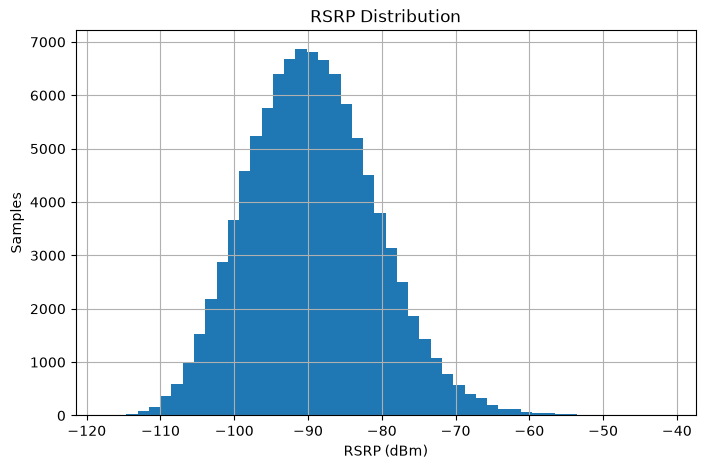

In [5]:
plt.figure(figsize=(8,5))

plt.hist(
    df["rsrp"],
    bins=50
)

plt.xlabel("RSRP (dBm)")
plt.ylabel("Samples")

plt.title("RSRP Distribution")

plt.grid(True)

plt.show()

In [6]:
df.groupby("environment")["rsrp"].mean()

environment
Rural      -86.155287
Suburban   -89.265563
Urban      -92.747677
Name: rsrp, dtype: float64

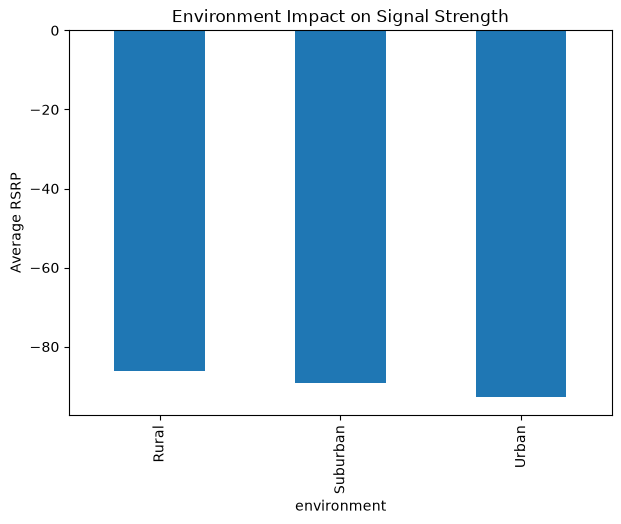

In [7]:
df.groupby("environment")["rsrp"].mean().plot(
    kind="bar",
    figsize=(7,5)
)

plt.ylabel("Average RSRP")
plt.title("Environment Impact on Signal Strength")

plt.show()

In [8]:
numeric_df = df.select_dtypes(
    include="number"
)

corr = numeric_df.corr()

corr["rsrp"].sort_values(
    ascending=False
)

received_power      1.000000
rsrp                1.000000
tx_power            0.283624
antenna_gain        0.232391
terrain_height      0.225838
user_density        0.005568
traffic_load        0.003778
tower_lat           0.002692
user_lat            0.000959
tower_height        0.000262
tower_lon          -0.000716
user_lon           -0.002437
rain_loss          -0.169128
building_density   -0.290229
shadow_fading      -0.325877
frequency          -0.569811
distance_km        -0.580536
path_loss          -0.856309
Name: rsrp, dtype: float64